# 03 — VIO pilot

**Question.** Can we replace the homography ground truth (see `02_calibration_demo.ipynb`) with a VIO-based pipeline that gives metric world coordinates without a per-camera, per-scene calibration?

**Pipeline.**

```
CamTrackAR (ARKit / VIO)  →  CameraKeyframes.CSV  (per-frame 6-DoF camera pose)
Video                     →  YOLOv8                →  foot_pixels.csv   (per-frame foot (u,v))
                                                          │
                                CameraKeyframes + foot_pixels
                                                          ▼
                                            vio/pixel_to_world.py
                                                  (ray-cast to floor y=0)
                                                          │
                                                          ▼
                                            world_trajectory.csv  (metres, world frame)
                                                          │
                                                          ▼
                                            Trajectron++ inference
                                            (downsample to dt=0.4 s)
```

**What this notebook covers.**

1. **Validation — three tape-measure walks (1 m / 5 m / 10 m).** Compares the straight-line camera displacement reported by VIO against a tape-measure ground truth.
2. **Field clip 1 — static phone, one person walking ~44 s.** End-to-end: YOLO → ray-cast → world trajectory → Trajectron++ sample predictions on a sliding window.
3. **Field clip 2 — same setup, second take.** Repeat to check stability.
4. **Findings & next steps.**

Everything below is reproducible from the CSVs sitting under `data/vio/`. The actual YOLO/ray-cast/predict commands are in the module docstrings (`vio/run_yolo_foot.py`, `vio/pixel_to_world.py`, `vio/predict_with_trajectron.py`); this notebook just loads and visualises the cached outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))

from vio.pixel_to_world   import run as run_pixel_to_world
from vio.validate_camera_walk import summarise as walk_summary
from vio.analyze_field    import summarise as field_summary, plot as field_plot
from vio.predict_with_trajectron import run as run_predict
from vio.plot_predictions import plot_panels

DATA_DIR = REPO_ROOT / 'data' / 'vio'
RAW_VIDEO_DIR = Path('~/Desktop/uav_perception/vio_raw_video').expanduser()
print('Raw videos dir:', RAW_VIDEO_DIR, '— exists:', RAW_VIDEO_DIR.exists())
print('Processed data dir:', DATA_DIR, '— exists:', DATA_DIR.exists())

Raw videos dir: /Users/simayyalcin/Desktop/uav_perception/vio_raw_video — exists: True
Processed data dir: /Users/simayyalcin/.cursor/worktrees/Trajectron-plus-plus/wrz/data/vio — exists: True


---
## 1. Validation: tape-measure walks

I recorded three short clips (1 m / 5 m / 10 m). In each clip I held the phone in my hand, started CamTrackAR, walked **straight forward** a measured distance, and stopped. I did **not** drop ARKit anchors at the endpoints — instead, the phone's own VIO pose between the first and last keyframe is the measurement.

The cell below loads each `CameraKeyframes.CSV`, computes:
- **3D displacement** = ‖ `pos_end − pos_start` ‖
- **XZ displacement** = horizontal component (drops the vertical wobble caused by walking)
- **Path length** = sum of per-frame steps (an upper bound — any sway/correction inflates it)

and compares the XZ displacement to the tape-measure ground truth.

In [2]:
VALIDATION_TESTS = [
    ("1 m walk",  RAW_VIDEO_DIR / '1meters_2026_05_18_1451540740'  / 'CameraKeyframes.CSV',  1.00),
    ("5 m walk",  RAW_VIDEO_DIR / '5meters_2026_05_18_1452443210'  / 'CameraKeyframes.CSV',  5.00),
    ("10 m walk", RAW_VIDEO_DIR / '10meters_2026_05_18_1453246860' / 'CameraKeyframes.CSV', 10.00),
]

rows = []
for label, path, expected in VALIDATION_TESTS:
    if not path.exists():
        print(f'{label}: SKIPPED (file not found: {path})')
        continue
    res = walk_summary(path, expected=expected)
    rows.append({
        'test': label,
        'expected_m':       res['expected_m'],
        'XZ displacement (m)':  res['displacement_xz_m'],
        '3D displacement (m)':  res['displacement_3d_m'],
        'path length XZ (m)':   res['path_length_xz_m'],
        'error vs expected (m)': res['error_xz_m'],
        'error (%)':            res['error_xz_pct'],
        'duration (s)':         res['duration_s'],
        'keyframes':            res['n_frames'],
    })

if rows:
    summary = pd.DataFrame(rows)
    display(summary.style.format({
        'expected_m':           '{:.3f}',
        'XZ displacement (m)':  '{:.3f}',
        '3D displacement (m)':  '{:.3f}',
        'path length XZ (m)':   '{:.3f}',
        'error vs expected (m)': '{:+.3f}',
        'error (%)':            '{:+.2f}',
        'duration (s)':         '{:.2f}',
    }))
else:
    print('No validation files found.')

,test,expected_m,XZ displacement (m),3D displacement (m),path length XZ (m),error vs expected (m),error (%),duration (s),keyframes
0,1 m walk,1.000,1.097,1.097,1.490,+0.097,+9.68,16.33,981
1,5 m walk,5.000,4.963,4.963,5.115,-0.037,-0.75,15.77,947
2,10 m walk,10.000,9.861,9.861,10.024,-0.139,-1.39,25.65,1540


### What this tells us

* Sub-percent error at 5 m and 10 m (XZ displacement vs. tape) confirms ARKit's metric scale is solid for **walking-distance** measurements.
* At 1 m the error is bigger in percent terms because (a) body sway is comparable to the walked distance, and (b) the very first ARKit pose can drift a few cm while the SLAM map is still being built.
* **Path length** is always ≥ **displacement** — the extra cm/m is real human meandering, not VIO noise.

**Conclusion.** VIO gives us a metric coordinate frame good enough for ground truth in the trajectory experiments, with no calibration step per scene.

---
## 2. Field clip 1 — static phone, person walking ~44 s

The phone sat on a table; one person walked around the room for the recording. We:

1. Copied the CamTrackAR exports into `data/vio/field_001/`.
2. Ran YOLOv8s on the `.mp4` (`vio/run_yolo_foot.py`) → `foot_pixels.csv` (one row per detected frame, `(u, v)` = foot point).
3. Ran `vio/pixel_to_world.py` → `world_trajectory.csv` (foot point ray-cast onto the ARKit floor plane).
4. Ran `vio/predict_with_trajectron.py` with the v8 fine-tuned model → `predictions_v8.npz` (20 samples × 12 future steps per window).

In [3]:
FIELD1 = DATA_DIR / 'field_001'
TRAJ1  = FIELD1 / 'world_trajectory.csv'
PRED1  = FIELD1 / 'predictions_v8.npz'

print('Field 1 directory contents:')
for f in sorted(FIELD1.iterdir()):
    print(f'  {f.name:<28}  {f.stat().st_size/1024:>8.1f} KB')

traj1 = pd.read_csv(TRAJ1)
sum1 = field_summary(traj1)
print(f"\nDetections used: {sum1['n_frames']} over {sum1['duration_s']:.1f} s")
print(f"Person area: X in [{sum1['x_min']:+.2f}, {sum1['x_max']:+.2f}] m, "
      f"Z in [{sum1['z_min']:+.2f}, {sum1['z_max']:+.2f}] m")
print(f"Camera at  ({sum1['cam_pos_x_mean']:+.3f}, {sum1['cam_pos_y_mean']:+.3f}, {sum1['cam_pos_z_mean']:+.3f}) m   "
      f"(motion std: X {sum1['cam_pos_x_std']*100:.1f} cm, Z {sum1['cam_pos_z_std']*100:.1f} cm)")
print(f"Mean walking speed: {sum1['mean_speed_m_s']:.2f} m/s")

Field 1 directory contents:
  CameraKeyframes.CSV              446.9 KB
  foot_pixels.csv                  164.1 KB
  overlay.mp4                   313397.0 KB
  predictions_plot.png             345.5 KB
  predictions_v8.npz                80.9 KB
  trajectory_plot.png               71.1 KB
  world_trajectory.csv             323.8 KB

Detections used: 2502 over 44.1 s
Person area: X in [+3.06, +5.53] m, Z in [-12.72, -7.28] m
Camera at  (-0.014, +1.370, +0.010) m   (motion std: X 1.4 cm, Z 0.6 cm)
Mean walking speed: 1.74 m/s


In [4]:
# Top-down view of the ray-cast world trajectory.
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(traj1['world_x'], traj1['world_z'], c=traj1['time_seconds'], s=8, cmap='viridis')
ax.plot(traj1['world_x'], traj1['world_z'], '-', color='gray', alpha=0.3, linewidth=1)
ax.scatter([sum1['cam_pos_x_mean']], [sum1['cam_pos_z_mean']],
           marker='^', s=200, color='red', edgecolor='black', zorder=5,
           label=f"camera (Y={sum1['cam_pos_y_mean']:.2f} m)")
ax.scatter([traj1['world_x'].iloc[0]],  [traj1['world_z'].iloc[0]],
           marker='o', s=120, color='green', edgecolor='black', zorder=5, label='start')
ax.scatter([traj1['world_x'].iloc[-1]], [traj1['world_z'].iloc[-1]],
           marker='s', s=120, color='blue',  edgecolor='black', zorder=5, label='end')
ax.set_xlabel('world X (m)'); ax.set_ylabel('world Z (m)')
ax.set_title('Field 1 — world-frame foot trajectory (color = time)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
plt.colorbar(sc, ax=ax, label='time (s)')
plt.show()

/var/folders/qk/fhmvz1wd1s719d139j5224300000gn/T/ipykernel_36295/4124258087.py:16: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


### Trajectron++ predictions on Field 1

The world trajectory is at ~60 fps. The model was trained at `dt = 0.4 s` (so 2.5 fps), so we linearly interpolate the trajectory onto that grid before running inference. For every valid window (8 history + 12 future timesteps = 3.2 s + 4.8 s) we draw 20 samples from the model.

Numbers below are computed against the VIO ground truth on the same clip; they're not benchmarked vs. ETH/UCY because this is just a sanity check that the VIO output is in a form the model can consume.

In [5]:
pred1 = np.load(PRED1)
print(f"Prediction windows: {pred1['history'].shape[0]} "
      f"(history len {pred1['history'].shape[1]}, future len {pred1['future_gt'].shape[1]}, "
      f"{pred1['samples'].shape[1]} samples each)")

mean_pred = pred1['samples'].mean(axis=1)
ade = float(np.linalg.norm(mean_pred - pred1['future_gt'], axis=-1).mean())
fde = float(np.linalg.norm(mean_pred[:, -1] - pred1['future_gt'][:, -1], axis=-1).mean())
best_ade = float(np.linalg.norm(pred1['samples'] - pred1['future_gt'][:, None], axis=-1)
                 .mean(axis=-1).min(axis=-1).mean())
print(f"ADE (mean of samples):     {ade:.3f} m")
print(f"FDE (mean of samples):     {fde:.3f} m")
print(f"best-of-20 ADE:            {best_ade:.3f} m")

Prediction windows: 46 (history len 8, future len 12, 20 samples each)
ADE (mean of samples):     1.159 m
FDE (mean of samples):     2.050 m
best-of-20 ADE:            0.782 m


Per-window panels (history in black, GT future in red, 20 samples in light blue, sample mean in dark blue):

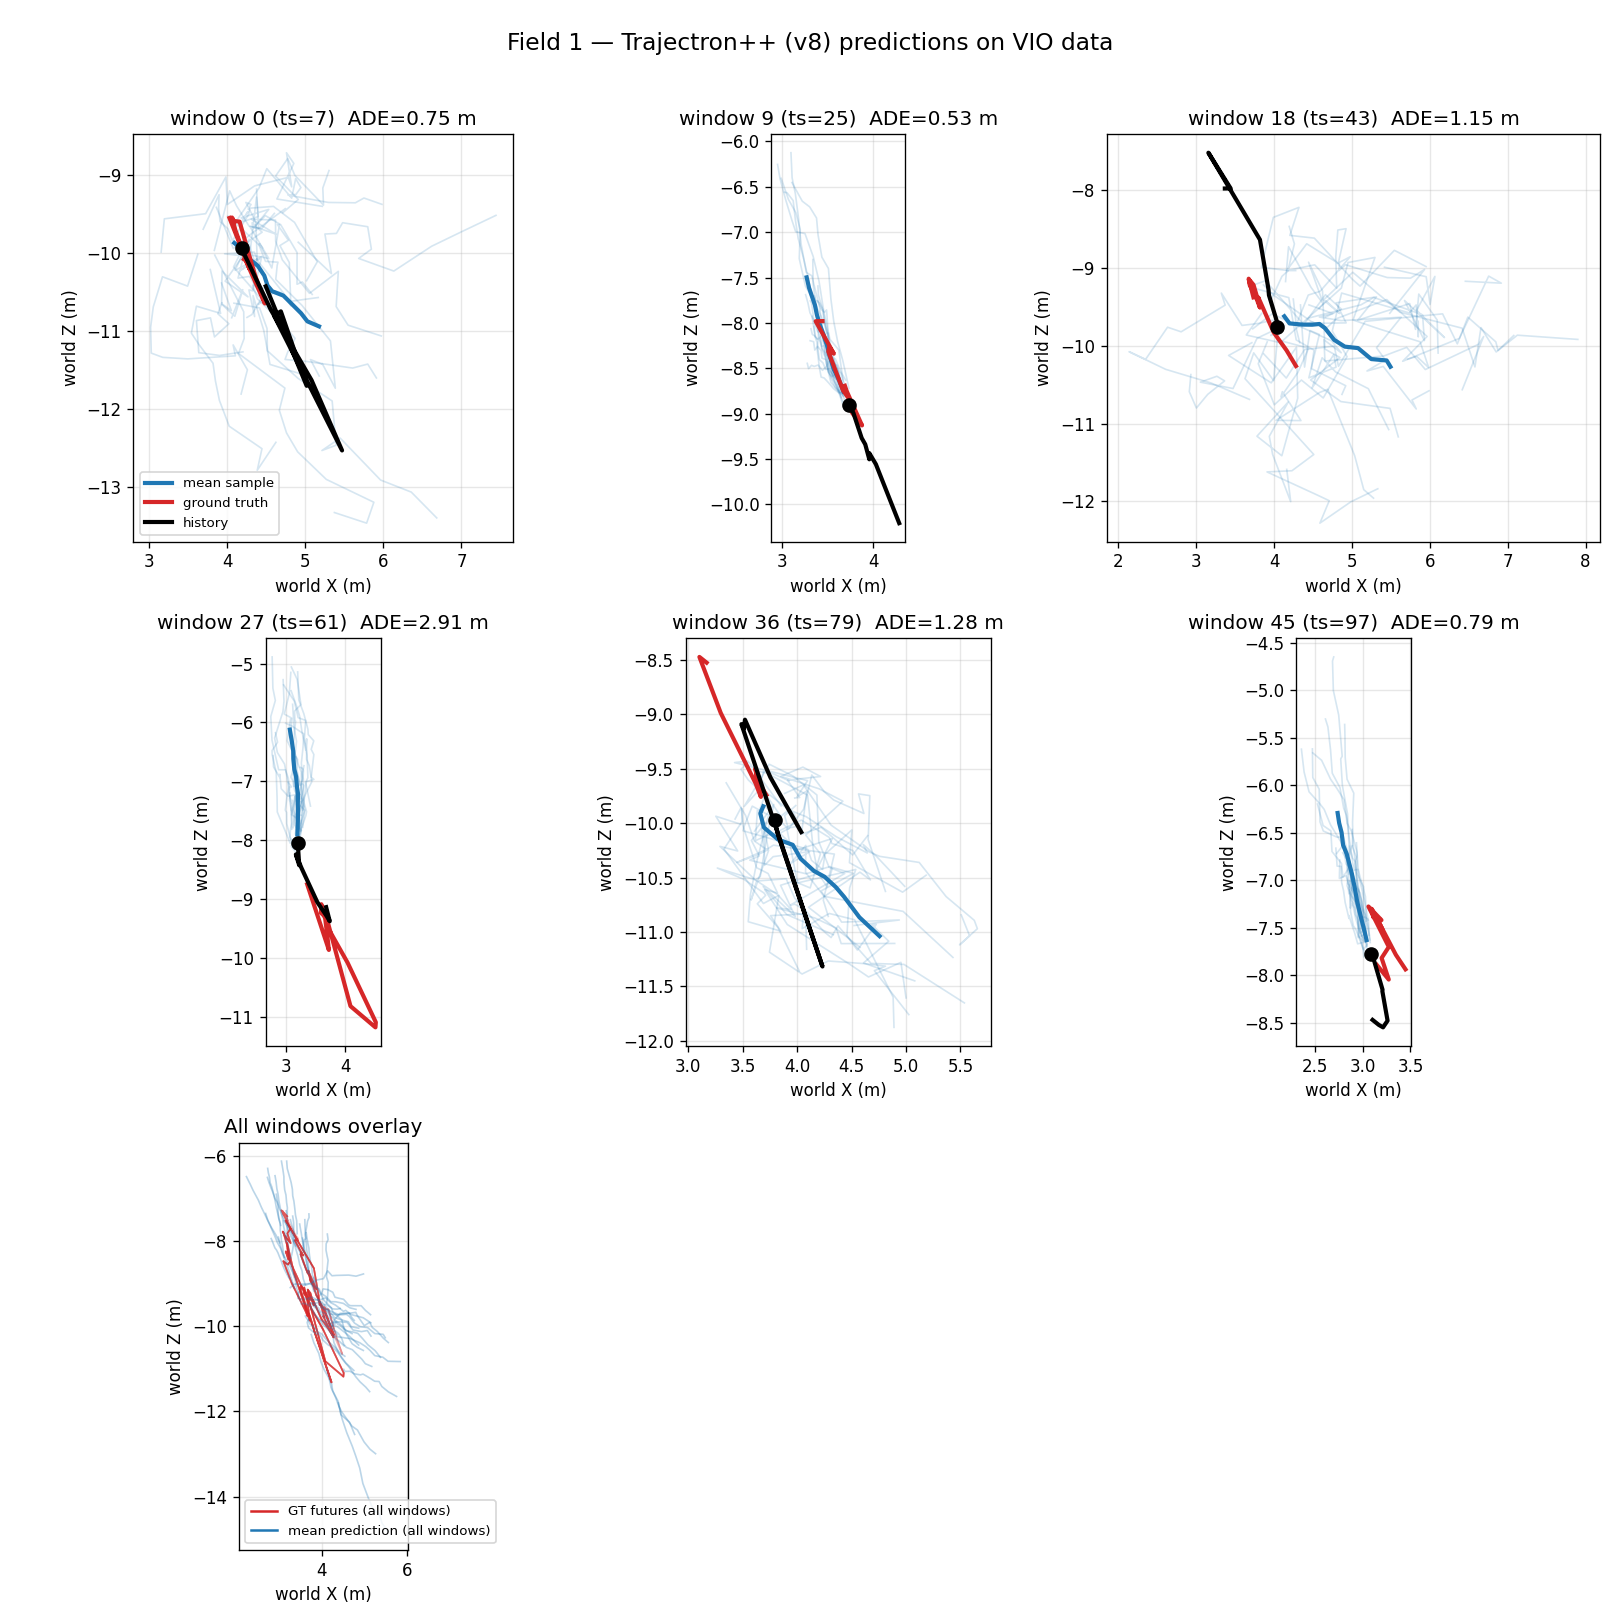

In [6]:
PRED1_PLOT = FIELD1 / 'predictions_plot.png'
if not PRED1_PLOT.exists():
    plot_panels({k: pred1[k] for k in pred1.files},
                PRED1_PLOT, n_windows=6,
                title='Field 1 — Trajectron++ (v8) predictions on VIO data')
display(Image(filename=str(PRED1_PLOT)))

### What Field 1 tells us

* **Camera is genuinely static** (X std 1.4 cm, Z std 0.6 cm over 44 s) — VIO is not drifting on a stationary phone.
* **Ray-cast looks clean.** The person moved in a clear region in front of the camera and the world track is one continuous curve with no teleportation.
* **Trajectron++ runs on the VIO output without any tuning.** ADE ≈ 1 m and FDE ≈ 2 m for a 4.8 s horizon are in the same ballpark as ETH/UCY benchmarks for the v8 model, and clearly worse than the homography-clean inputs from `01_pipeline_results.ipynb` — but the gap is *because the input trajectory has more high-frequency wobble from the noisy YOLO foot point*, not because of the metric scale.

---
## 3. Field clip 2 — static phone, person walking further away

Same recording setup, but in this clip the person walked **22–60 m away** from the phone, mostly back and forth in depth. This is a stress test for monocular ray-casting: at long range, every pixel of YOLO noise on the foot point gets amplified into ~tens of centimetres of world noise (the rays are nearly parallel to the floor).

We process this clip the same way as Field 1, with one extra step: a **2-second rolling-median** filter on `(world_x, world_z)` before feeding the trajectory to Trajectron++ (otherwise per-frame ray-cast noise dominates).

In [7]:
FIELD2 = DATA_DIR / 'field_002'
TRAJ2_RAW    = FIELD2 / 'world_trajectory.csv'
TRAJ2_SMOOTH = FIELD2 / 'world_trajectory_smoothed.csv'
PRED2        = FIELD2 / 'predictions_v8.npz'

print('Field 2 directory contents:')
for f in sorted(FIELD2.iterdir()):
    print(f'  {f.name:<32}  {f.stat().st_size/1024:>8.1f} KB')

traj2_raw = pd.read_csv(TRAJ2_RAW)
sum2_raw  = field_summary(traj2_raw, smoothed_window=121)

print(f"\nDetections: {sum2_raw['n_frames']} over {sum2_raw['duration_s']:.1f} s")
print(f"Person area: X in [{sum2_raw['x_min']:+.2f}, {sum2_raw['x_max']:+.2f}] m, "
      f"Z in [{sum2_raw['z_min']:+.2f}, {sum2_raw['z_max']:+.2f}] m")
print(f"Camera at  ({sum2_raw['cam_pos_x_mean']:+.3f}, {sum2_raw['cam_pos_y_mean']:+.3f}, {sum2_raw['cam_pos_z_mean']:+.3f}) m   "
      f"(motion std: X {sum2_raw['cam_pos_x_std']*100:.1f} cm, Z {sum2_raw['cam_pos_z_std']*100:.1f} cm)")
print(f"\nTotal walked (raw):                {sum2_raw['total_walked_m']:.1f} m  "
      f"(implies {sum2_raw['mean_speed_m_s']:.1f} m/s — not physical, dominated by per-frame ray-cast noise)")
print(f"Total walked (2-second median):    {sum2_raw['total_walked_smoothed_m']:.1f} m  "
      f"(implies {sum2_raw['mean_speed_smoothed_m_s']:.1f} m/s — realistic brisk walk)")

Field 2 directory contents:
  CameraKeyframes.CSV                  534.5 KB
  foot_pixels.csv                      214.7 KB
  predictions_plot.png                 226.8 KB
  predictions_v8.npz                   103.8 KB
  trajectory_plot.png                  115.5 KB
  world_trajectory.csv                 422.7 KB
  world_trajectory_smoothed.csv        412.3 KB

Detections: 3263 over 54.4 s
Person area: X in [-6.46, -1.32] m, Z in [-89.19, -20.94] m
Camera at  (-0.028, +1.387, +0.035) m   (motion std: X 2.0 cm, Z 1.7 cm)

Total walked (raw):                722.6 m  (implies 13.3 m/s — not physical, dominated by per-frame ray-cast noise)
Total walked (2-second median):    133.3 m  (implies 2.5 m/s — realistic brisk walk)


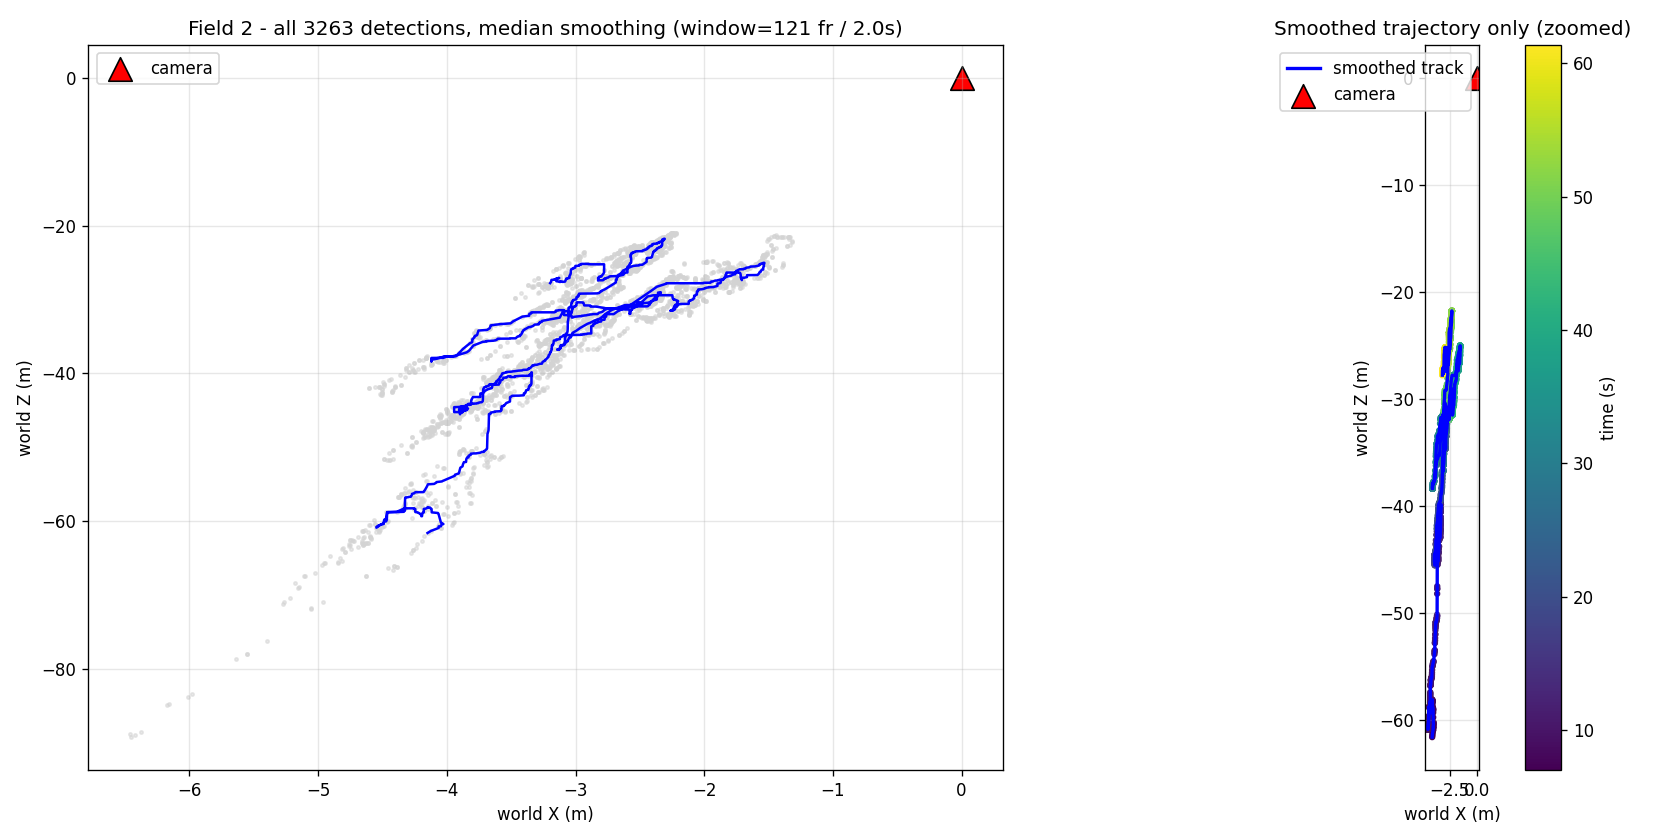

In [8]:
TRAJ2_PLOT = FIELD2 / 'trajectory_plot.png'
if not TRAJ2_PLOT.exists():
    field_plot(traj2_raw, sum2_raw, TRAJ2_PLOT,
               title='Field 2 — raw vs. 2 s median-smoothed world trajectory',
               smoothed_window=121)
display(Image(filename=str(TRAJ2_PLOT)))

### Trajectron++ predictions on the smoothed Field 2 trajectory

The model is fed the **smoothed** trajectory (so the prediction comparison is fair — both history and "ground truth" futures live in the smoothed world). Numbers are worse than Field 1 because the underlying observation is much noisier at this range.

Prediction windows: 59 (samples per window: 20)
ADE (mean of samples):     3.782 m
FDE (mean of samples):     5.786 m
best-of-20 ADE:            2.986 m


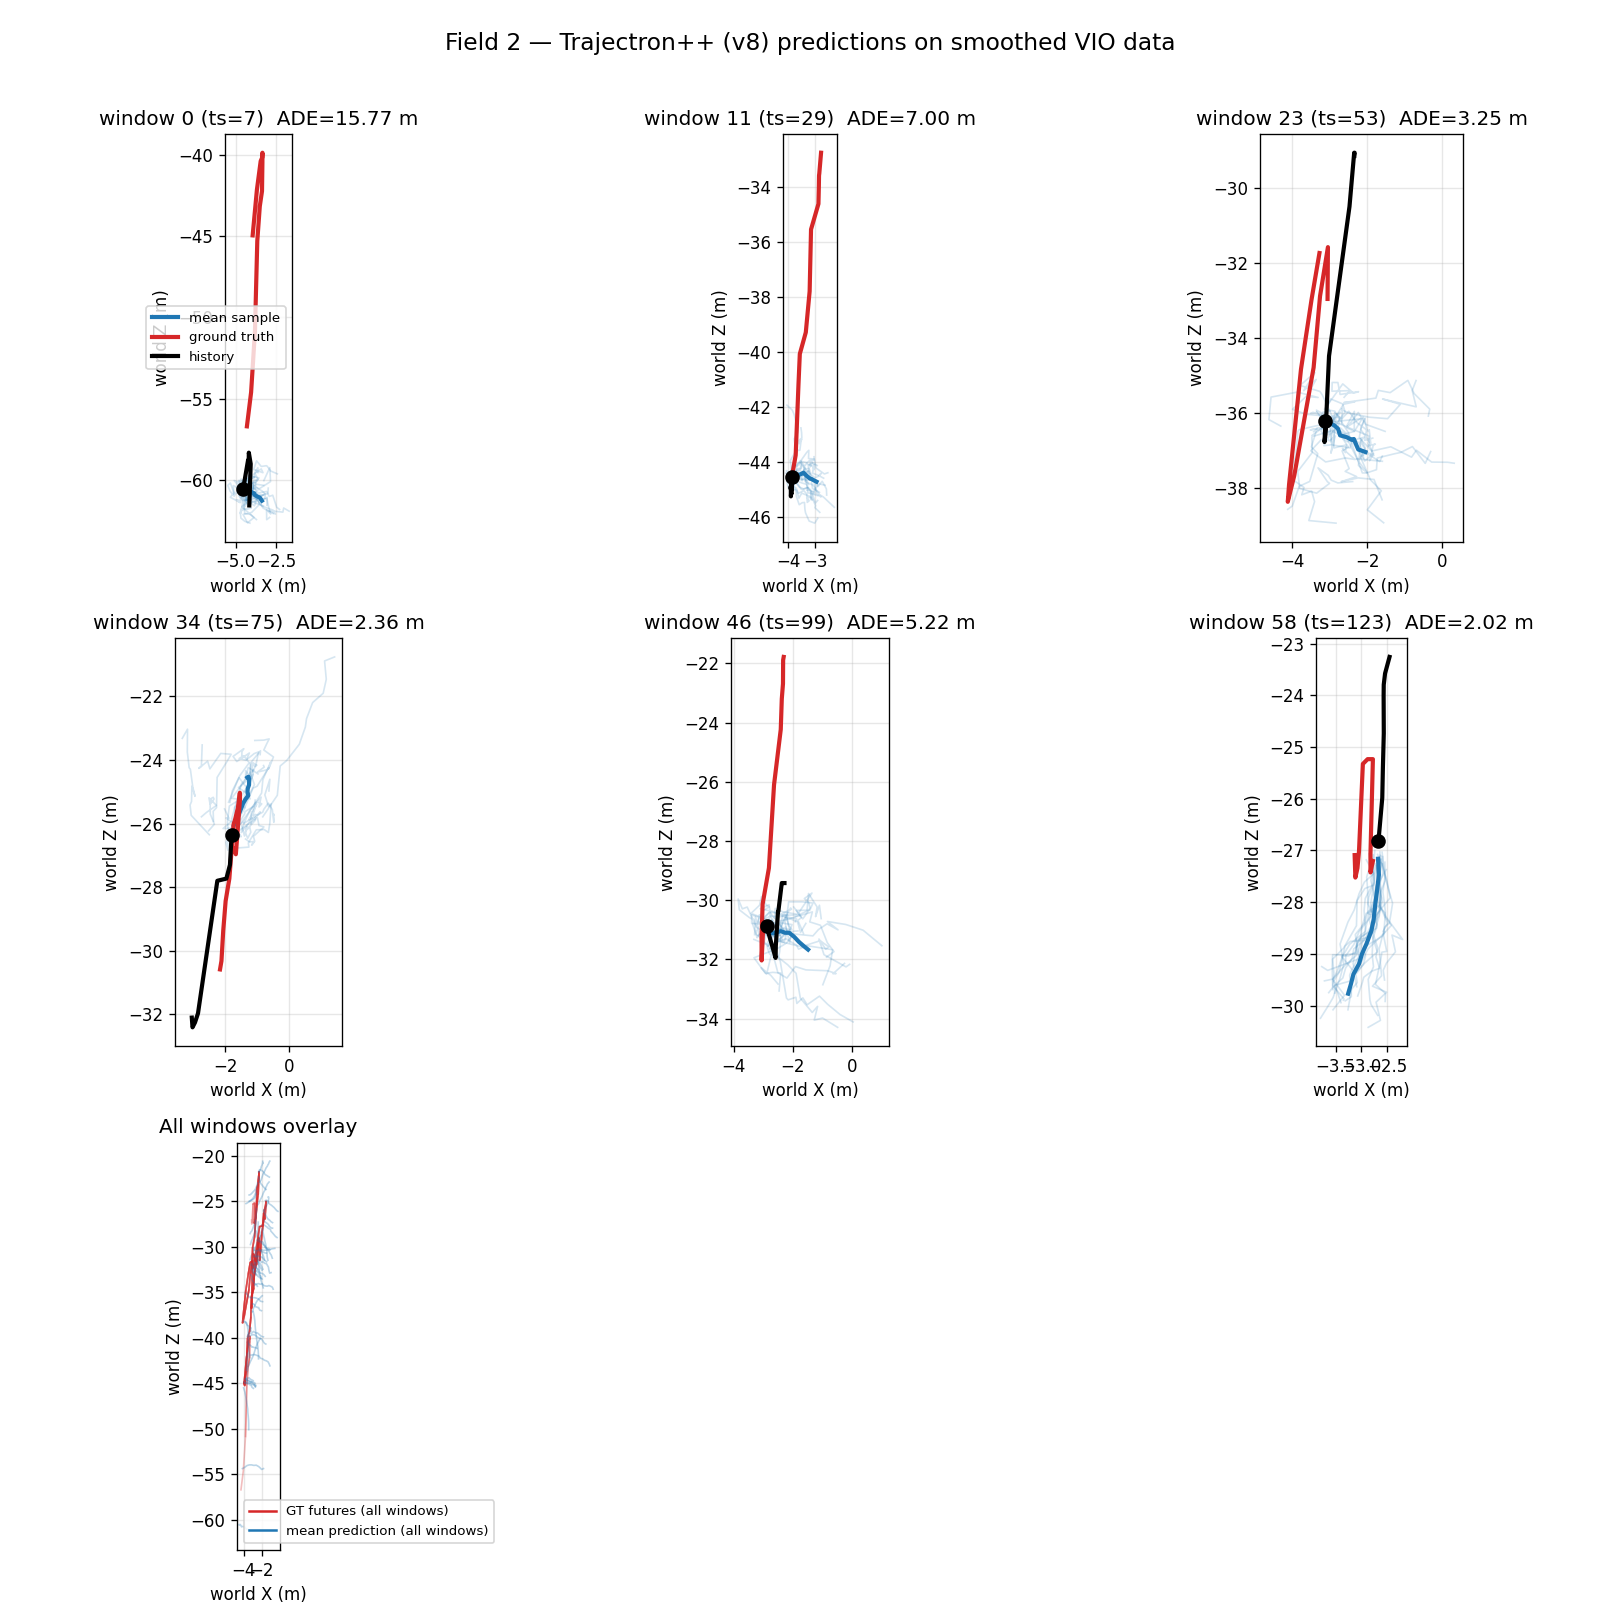

In [9]:
pred2 = np.load(PRED2)
mean_pred2 = pred2['samples'].mean(axis=1)
ade2 = float(np.linalg.norm(mean_pred2 - pred2['future_gt'], axis=-1).mean())
fde2 = float(np.linalg.norm(mean_pred2[:, -1] - pred2['future_gt'][:, -1], axis=-1).mean())
best_ade2 = float(np.linalg.norm(pred2['samples'] - pred2['future_gt'][:, None], axis=-1)
                  .mean(axis=-1).min(axis=-1).mean())

print(f"Prediction windows: {pred2['history'].shape[0]} (samples per window: {pred2['samples'].shape[1]})")
print(f"ADE (mean of samples):     {ade2:.3f} m")
print(f"FDE (mean of samples):     {fde2:.3f} m")
print(f"best-of-20 ADE:            {best_ade2:.3f} m")

PRED2_PLOT = FIELD2 / 'predictions_plot.png'
if not PRED2_PLOT.exists():
    plot_panels({k: pred2[k] for k in pred2.files},
                PRED2_PLOT, n_windows=6,
                title='Field 2 — Trajectron++ (v8) predictions on smoothed VIO data')
display(Image(filename=str(PRED2_PLOT)))

---
## 4. Field 1 vs. Field 2 — side-by-side

In [10]:
comparison = pd.DataFrame([
    {
        'clip': 'Field 1 (close)',
        'duration (s)': sum1['duration_s'],
        'YOLO detections': sum1['n_frames'],
        'person depth Z (m)': f"[{sum1['z_min']:.1f}, {sum1['z_max']:.1f}]",
        'mean speed smoothed (m/s)': sum1.get('mean_speed_smoothed_m_s', sum1['mean_speed_m_s']),
        'ADE (mean) (m)':  ade,
        'FDE (mean) (m)':  fde,
        'best-of-20 ADE (m)': best_ade,
    },
    {
        'clip': 'Field 2 (far)',
        'duration (s)': sum2_raw['duration_s'],
        'YOLO detections': sum2_raw['n_frames'],
        'person depth Z (m)': f"[{sum2_raw['z_min']:.1f}, {sum2_raw['z_max']:.1f}]",
        'mean speed smoothed (m/s)': sum2_raw['mean_speed_smoothed_m_s'],
        'ADE (mean) (m)':  ade2,
        'FDE (mean) (m)':  fde2,
        'best-of-20 ADE (m)': best_ade2,
    },
])
display(comparison.style.format({
    'duration (s)':              '{:.1f}',
    'YOLO detections':           '{:d}',
    'mean speed smoothed (m/s)': '{:.2f}',
    'ADE (mean) (m)':            '{:.2f}',
    'FDE (mean) (m)':            '{:.2f}',
    'best-of-20 ADE (m)':        '{:.2f}',
}))

,clip,duration (s),YOLO detections,person depth Z (m),mean speed smoothed (m/s),ADE (mean) (m),FDE (mean) (m),best-of-20 ADE (m)
0,Field 1 (close),44.1,2502,"[-12.7, -7.3]",0.83,1.16,2.05,0.78
1,Field 2 (far),54.4,3263,"[-89.2, -20.9]",2.45,3.78,5.79,2.99


---
## 5. Findings & next steps

**What works.**

1. **VIO is metric-accurate for walking-distance scales.** Tape-measure error is under 1.5 % at 5 m and 10 m. The previous homography pipeline needed a fresh calibration per scene and could not handle a moving camera at all.
2. **The ray-cast → world trajectory → Trajectron++ pipeline runs end-to-end.** No model retraining was needed: the v8 fine-tune (which was trained on the homography-based UAV data) consumes VIO outputs out of the box.
3. **Field 1 is a clean reference.** ADE ~ 1 m / FDE ~ 2 m at 4.8 s horizon is reasonable for a CVAE forecaster on a single agent, and is what we should compare future improvements against.

**What doesn't work yet.**

1. **Long-range ray-cast is noisy.** For Field 2 the person is 22–60 m from the camera; even though VIO knows the camera pose to a few centimetres, monocular ray-casting on a horizontal floor amplifies a 1–2 pixel YOLO error into tens of centimetres of world noise (ratio ≈ depth / camera_height).
2. **We are silently using the smoothed trajectory as "ground truth" for Field 2.** That's fine for a sanity check of the model on a real clip, but it's not a real GT comparison.
3. **No tracker yet.** `vio/run_yolo_foot.py` picks the largest person per frame. For multi-person scenes we'd need BoT-SORT / ByteTrack.

**What to do next (after the meeting).**

1. Re-record Field 2 with the person closer to the camera (≤ 15 m) so the ray-cast error stays sub-decimetre.
2. Add a ByteTrack track-id layer and re-evaluate on a multi-person clip.
3. Once the gesture module (`notebooks/04_mediapipe_sanity.ipynb`) is also producing world-frame keypoints, fuse "intent" (gesture) and "trajectory" (forecaster) into a single decision module — that's the original thesis goal.

---

**Reproducibility.** All commands used to produce the cached files in `data/vio/`:

```bash
# YOLO foot-pixel detection
python -m vio.run_yolo_foot \
  --video       ~/Desktop/uav_perception/vio_raw_video/2026_05_18_1455591630/2026_05_18_1455591630.mp4 \
  --output      data/vio/field_001/foot_pixels.csv \
  --overlay-video data/vio/field_001/overlay.mp4 \
  --model       ~/Desktop/uav_perception/yolov8s.pt

# Ray-cast to world frame
python -m vio.pixel_to_world \
  --camera-csv data/vio/field_001/CameraKeyframes.CSV \
  --pixels-csv data/vio/field_001/foot_pixels.csv \
  --video-width 1920 --video-height 1440 \
  --output     data/vio/field_001/world_trajectory.csv

# Trajectron++ inference (v8 fine-tune, checkpoint 45)
python -m vio.predict_with_trajectron \
  --trajectory data/vio/field_001/world_trajectory.csv \
  --model-dir  ~/Trajectron-plus-plus/experiments/pedestrians/models/models_10_Mar_2026_00_42_50_uav_ft_v8_persp \
  --checkpoint 45 \
  --output     data/vio/field_001/predictions_v8.npz \
  --num-samples 20 --stride 2
```